## P25_37b

- Ok first think I want to figure out here is if we can meaninfully see activations change during sweeps
- I mean, the fc layer stuff is going to be trivial
- Really wondering about early layers ya know? I feel like there should be something there!
- Also I'm tempted to show the 2d sweeps and little arrows following the curves in matplotlib, let's make that plan A, and then fall back to manim if we needs to

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, math, re
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models.resnet import ResNet, BasicBlock

RUNS = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")                       # <-- output dir of train_depth_sweep.py
DATA = Path("/home/stephen/imagenet")     # <-- edit
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
MODELS = [m for m in MODEL_DEPTHS if (RUNS / m).exists()]

def color_of(name):
    """Plain nets: dark->light with depth. ResNet: red."""
    if name == "resnet74":
        return "crimson"
    depths = sorted(d for m, d in MODEL_DEPTHS.items() if m != "resnet74")
    return plt.cm.viridis(depths.index(MODEL_DEPTHS[name]) / (len(depths) - 1))

print(torch.__version__, device, "| runs found:", MODELS)

2.12.1+cu130 cuda | runs found: ['plain8', 'plain14', 'plain20', 'plain26', 'plain34', 'plain56', 'plain74', 'resnet74']


In [3]:
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

In [4]:
# --- model definitions (mirrors train_depth_sweep.py) ---
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def blocks_of(model):
    return [b for s in (model.layer1, model.layer2, model.layer3, model.layer4)
            if isinstance(s, nn.Sequential) for b in s]

In [5]:
def list_ckpts(name):
    return sorted(int(re.search(r"(\d+)", p.stem).group(1))
                  for p in (RUNS / name).glob("ckpt_step*.pt"))

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

print("plain74 checkpoints:", list_ckpts("plain74")[:5], "...",
      list_ckpts("plain74")[-2:])

plain74 checkpoints: [1000, 2000, 3000, 4000, 5000] ... [99000, 100000]


In [6]:
model=load_model('plain8')
# model=load_model('plain14')

In [7]:
# --- validation data (same transforms as training script) ---
import torchvision.datasets as dsets, torchvision.transforms as T

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
               T.Normalize(MEAN, STD)]))
val_loader = torch.utils.data.DataLoader(val_ds, 64, shuffle=True,
    num_workers=4, pin_memory=True)

# wnid -> human-readable name (Kaggle CLS-LOC ships this mapping)
wnid_words = {}
mapping = DATA / "LOC_synset_mapping.txt"
if mapping.exists():
    for line in open(mapping):
        wnid, words = line.strip().split(" ", 1)
        wnid_words[wnid] = words.split(",")[0]

def class_name(idx):
    if 0 <= idx < len(val_ds.classes):
        wnid = val_ds.classes[idx]
        return wnid_words.get(wnid, wnid)
    return f"cls{idx}"

def denorm(x):  # CHW tensor -> HWC numpy in [0,1] for imshow
    img = x.cpu() * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

print(len(val_ds), "val images,", len(val_ds.classes), "classes")

50000 val images, 1000 classes


In [8]:
# @torch.no_grad()
# def validate(model, loader):
#     model.eval()
#     top1 = top5 = total = 0
#     for x, y in tqdm(loader, desc="val"):
#         x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
#         with torch.amp.autocast(device, enabled=(device == "cuda")):
#             logits = model(x)
#         _, pred5 = logits.topk(5, dim=1)
#         correct = pred5.eq(y.unsqueeze(1))
#         top1 += correct[:, 0].sum().item()
#         top5 += correct.any(dim=1).sum().item()
#         total += y.numel()
#     return top1 / total, top5 / total

# acc1, acc5 = validate(model, val_loader)
# print(f"top-1: {acc1:.4f}   top-5: {acc5:.4f}")

In [9]:
# ---- gradient-ranked sweeps over many random val images (all fp32) ----
LAYER_IDXS = [0, 1, 2, 3, -4, -3, -2, -1]  # layers to iterate through
N_IMAGES   = 256                 # random val images for the big run
TOP_N      = 20                  # top-N weights by |grad| per model per layer
SPAN       = 2.5
N_POINTS   = 128
IMG_SEED   = 25                  # seeds which images get chosen
PLOT_DELTA = False

rng = np.random.default_rng(IMG_SEED)
img_idxs = rng.choice(len(val_ds), size=N_IMAGES, replace=False)
# print(f"images: {list(img_idxs)}")

def load_image(idx):
    x, y = val_ds[idx]
    return x.unsqueeze(0).to(device), torch.tensor([y], device=device)

crit = nn.CrossEntropyLoss()

@torch.no_grad()
def batch_loss_fp32(model, x, y):
    return crit(model(x), y).item()

@torch.no_grad()
def correct_ans_conf(model, x, y):
    return torch.nn.Softmax()(model(x))[0, y.item()].item()

def layer_grad(model, layer, x, y):
    """|dL/dw| for one layer at the trained point, single backward, fp32."""
    model.zero_grad(set_to_none=True)
    loss = crit(model(x), y)
    loss.backward()
    g = layer.weight.grad.detach().flatten().clone()
    model.zero_grad(set_to_none=True)
    return g

def weighted_layers(model):
    """(name, module) for convs + fc in forward order, excluding 1x1 shortcuts."""
    return [(n, m) for n, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear)) and "downsample" not in n]

@torch.no_grad()
def sweep_weight(model, layer, flat_idx, x, y, mode='loss', span=SPAN, n=N_POINTS):
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    # vals = np.linspace(w0 - span, w0 + span, n)
    vals = np.linspace(-span, span, n)
    res = np.empty(n)
    for i, v in enumerate(vals):
        w[flat_idx] = v
        if mode=='loss': res[i] = batch_loss_fp32(model, x, y)
        elif mode=='conf': res[i] = correct_ans_conf(model, x, y)
        else: print('nah bro')
    w[flat_idx] = w0
    return vals, res, w0

## Contenders for wrong examples from experiments in p25_37a

d14
- 3294 Sea Snake
- 10262 Flat coated retriever
- 24790 China Cavinet
- 30669 Joystick
- 42241 Switch

d8
- 10262 Flat coated retriever
- 12943 Samoyed
- 21849 Beach wagon
- 27083 Drum
- 39209 Screw driver
- 41463 Streetcar
- 42096 Sweatshirt
- 42241 Swtich

In [10]:
img_idx=39209 

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()
print(wnid_words[val_ds.classes[yhat_index]])

screwdriver 0.05649815499782562
letter opener


/home/stephen/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [11]:
# from PIL import Image
# img = Image.fromarray((denorm(x[0])*255).astype('uint8'))
# img.save("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p25/screwdriver.jpg")

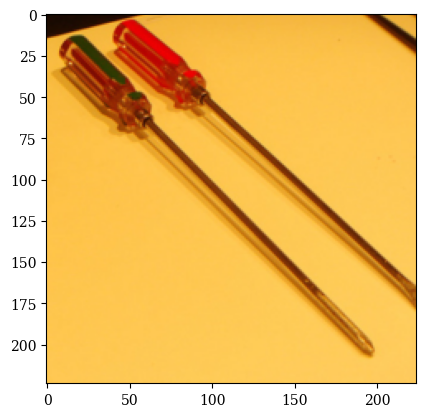

In [12]:
plt.imshow(denorm(x[0]))

screwdriver 0.05649815499782562


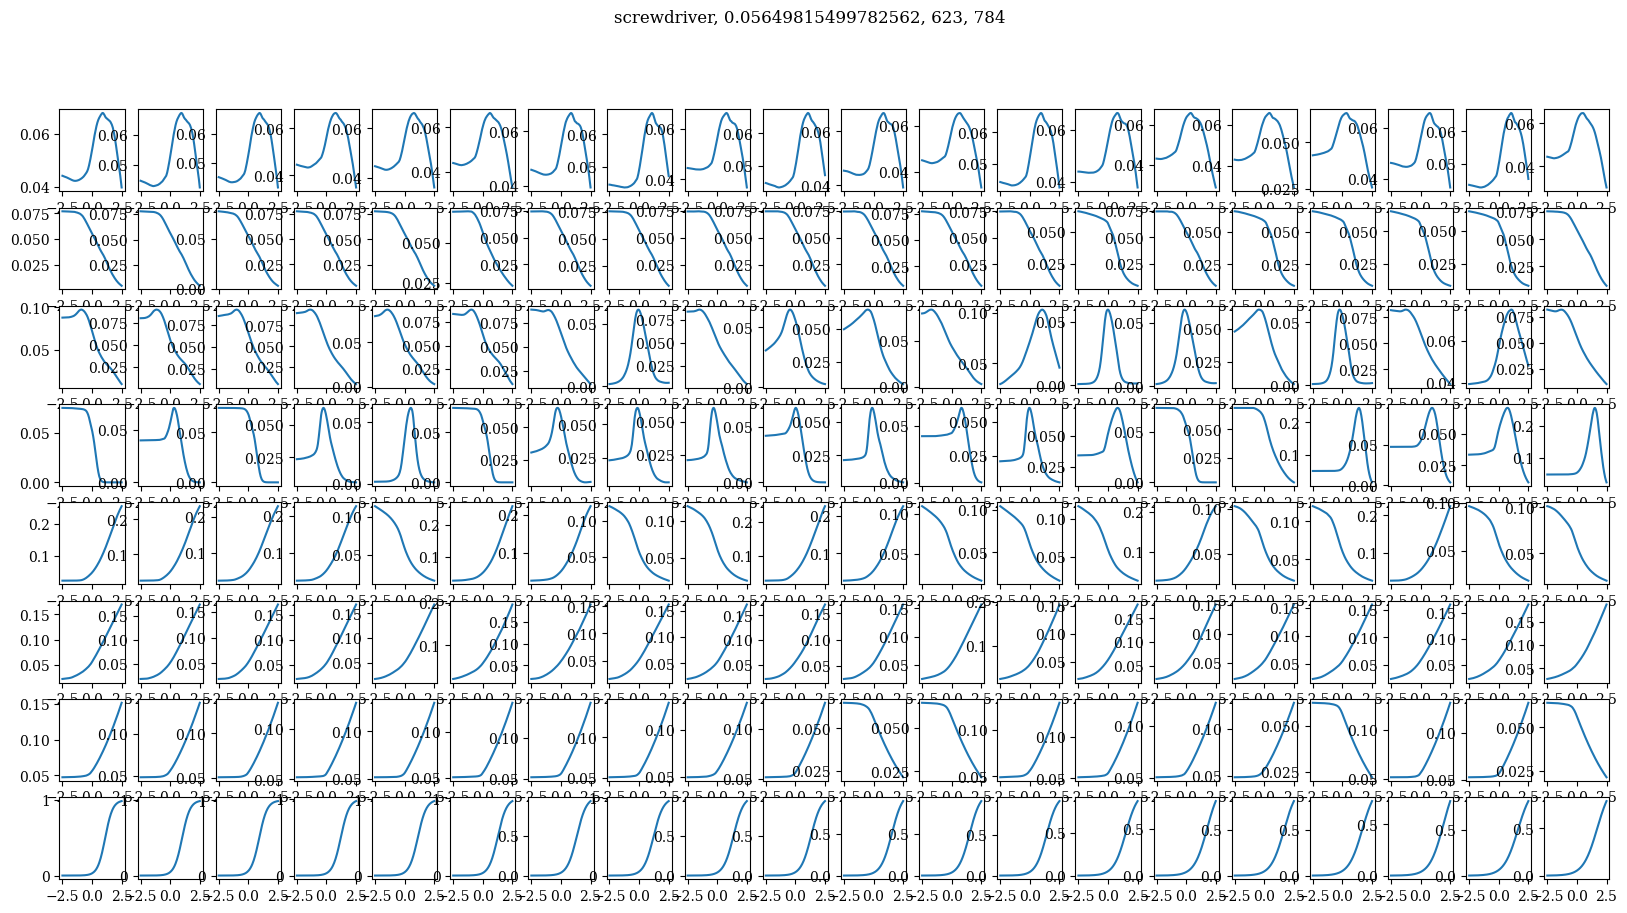

In [13]:
x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

fig=plt.figure(0, (20,10))
fig_count=1
for i, li in enumerate(LAYER_IDXS):
    name, layer = weighted_layers(model)[li]
    g = layer_grad(model,   layer,   x, y)
    
    picks = {}   # flat_idx -> list of (source, rank, gradval)
    vals, idxs = g.abs().topk(TOP_N)
    for rank, (v, fi) in enumerate(zip(vals.tolist(), idxs.tolist())):
        picks.setdefault(fi, []).append(('plain', rank, v))
    
    for j, (flat_idx, sources) in enumerate(picks.items()):
        # flat_idx=133 
        sources=[('plain', 0, 4.481142044067383)]
        
        coord = np.unravel_index(flat_idx, layer.weight.shape)
        vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')

        ax=fig.add_subplot(len(LAYER_IDXS), len(picks), fig_count)
        fig_count+=1
        ax.plot(vals, res)
        # plt.axis('off')
        # plt.title(f"layer {li} ({name})  w {flat_idx} {coord}  " f"img {img_idx} ({cls})")
    plt.suptitle(str(wnid_words[cls]) +', ' +str(correct_ans_conf(model, x, y))+', '+str(yhat_index)+', '+str(y.item()))


- Ok let me get some sweeps exported here so I can experiment with them in manim
- Thinking I just start with highest grad ones, and then work backwards from there

In [14]:
model=load_model('plain8')

In [15]:
img_idx=39209 
TOP_N = 256

In [16]:
x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

screwdriver 0.05649815499782562


In [17]:
y.item()

784

In [18]:
print(wnid_words[val_ds.classes[yhat_index]])

letter opener


In [19]:
probs=torch.nn.Softmax(dim=0)(model(x).detach().ravel())

In [20]:
probs.argmax()

tensor(623, device='cuda:0')

In [21]:
probs.max()

tensor(0.0900, device='cuda:0')

In [22]:
# li=-1 #Fc layer bro
# param_index=0 #220 is nice

# name, layer = weighted_layers(model)[li]
# g = layer_grad(model, layer,   x, y)
# vals, idxs = g.abs().topk(TOP_N)

# flat_idx=idxs[param_index].item()
# coord = np.unravel_index(flat_idx, layer.weight.shape)

# with torch.no_grad():
#     w = layer.weight.view(-1)
#     w[flat_idx] = -2.5
#     c=correct_ans_conf(model, x, y)
#     print(w[flat_idx].item(), c)

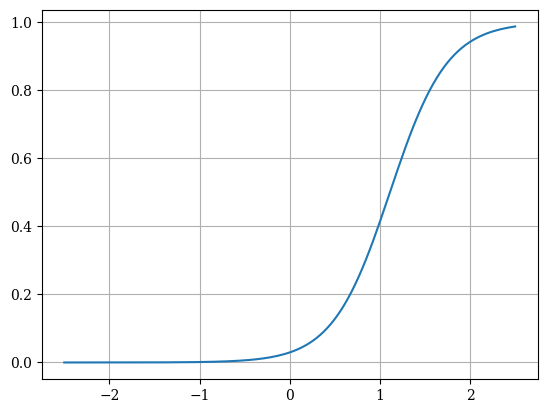

In [23]:
li=-1 #Fc layer bro
param_index=0 #220 is nice

name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

In [24]:
x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

screwdriver 0.05649815499782562


In [25]:
yhat_index

623

In [26]:
# print(wnid_words[val_ds.classes[yhat_index]])

In [27]:
# --- cache all intermediate activations through a model ---
class ActivationCache:
    """with ActivationCache(model) as cache: model(x)  ->  cache["layer3.5.bn2"]
    Hooks every leaf module (+ the residual blocks and stages themselves),
    stores detached outputs keyed by qualified module name, in forward order."""
    def __init__(self, model, to_cpu=True, leaf_only=False):
        self.model, self.to_cpu, self.leaf_only = model, to_cpu, leaf_only
        self.cache, self.handles = {}, []

    def _keep(self, name, mod):
        if name == "":                      # the model itself
            return False
        if self.leaf_only:
            return len(list(mod.children())) == 0
        return not isinstance(mod, (nn.Sequential, nn.Identity))

    def __enter__(self):
        def hook(name):
            def fn(mod, inp, out):
                if torch.is_tensor(out):
                    self.cache[name] = out.detach().cpu() if self.to_cpu else out.detach()
            return fn
        for name, mod in self.model.named_modules():
            if self._keep(name, mod):
                self.handles.append(mod.register_forward_hook(hook(name)))
        return self.cache

    def __exit__(self, *a):
        for h in self.handles:
            h.remove()
        self.handles.clear()

In [28]:
def style_ax(ax, color=CHILL_BROWN, tick_fontsize=12, keep_spines=False):
    if keep_spines: ax.spines[:].set_color(color)
    else: ax.spines[:].set_visible(False)
    ax.tick_params(colors=color, which='both', labelsize=tick_fontsize)
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

## Export activations as we swerp

### Swerp 1 

In [29]:
SPAN       = 2.5
N_POINTS   = 128
TOP_N= 256

In [30]:
li=-1
param_index=0 #220 is nice

name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)

In [31]:
# w[flat_idx].item() #initial value for this paremeter

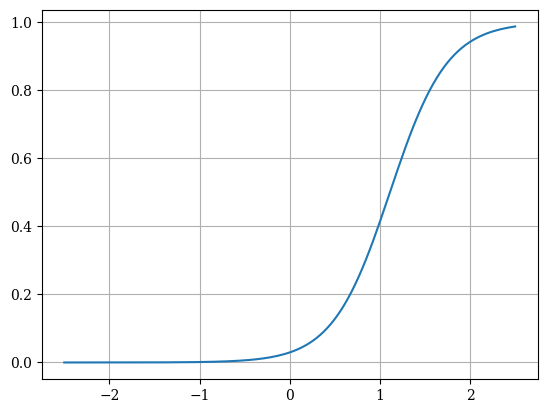

In [32]:
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

In [33]:
coord

(np.int64(784), np.int64(103))

In [34]:
save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p26_sweep_1_cache')
save_dir.mkdir(exist_ok=True)

li=0 #Fc layer bro
param_index=0

name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)

with torch.no_grad():
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(-SPAN, SPAN, N_POINTS)
    
    for i, v in enumerate(vals):
        w[flat_idx] = v
        with ActivationCache(model) as cache:
            model(x)

        cache_np={k:v.cpu().numpy() for k,v in cache.items()}
        np.save(save_dir/str(i).zfill(3), cache_np)

    w[flat_idx] = w0

Ok now matplotlib plots as we sweep - probs, and weight curves. 

In [35]:
# model=load_model('plain8')

  0%|                                                  | 0/128 [00:00<?, ?it/s]/tmp/ipykernel_3484667/3116820424.py:25: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (2.0, 8), facecolor='k')
100%|████████████████████████████████████████| 128/128 [00:06<00:00, 20.87it/s]


<Figure size 640x480 with 0 Axes>

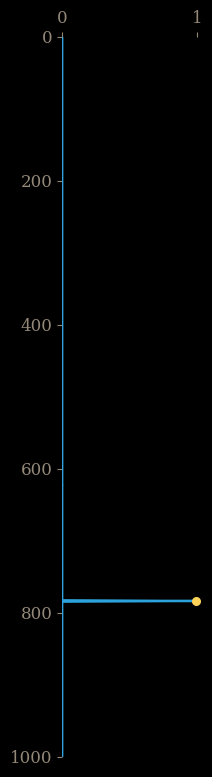

In [36]:
save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p26_sweep_1_probs')
save_dir.mkdir(exist_ok=True)

li=-1
param_index=0 #220

name, layer = weighted_layers(model)[li]
g = layer_grad(model, layer,   x, y)
vals, idxs = g.abs().topk(TOP_N)

flat_idx=idxs[param_index].item()
coord = np.unravel_index(flat_idx, layer.weight.shape)

with torch.no_grad():
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(-SPAN, SPAN, N_POINTS)
    
    for i, v in enumerate(tqdm(vals)):
        w[flat_idx] = v
        with ActivationCache(model) as cache:
            model(x)
            
        plt.clf()
        fig=plt.figure(0, (2.0, 8), facecolor='k')
        # ax=fig.add_subplot(111,facecolor='k')
        ax = fig.add_axes([0.25, 0.03, 0.7, 0.9],facecolor='k')
        probs=torch.nn.Softmax(dim=0)(cache['fc'].ravel())
        plt.plot(probs, np.arange(1000), c=BLUE, linewidth=1.65)
        ax.scatter(probs[784], 784, c=YELLOW, s=30, zorder=100)
        plt.ylim([1000,0])
        ax.xaxis.tick_top()
        ax.set_xlim(left=0)
        # plt.ylim([]) #HAVE TO SET TO THIS TO AVOID THE WIGGLE WIGGLES
        style_ax(ax)
    
        plt.savefig(save_dir/str(i).zfill(3), dpi=300) # , bbox_inches='tight')

    w[flat_idx] = w0

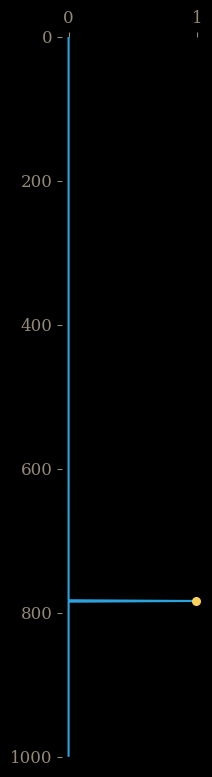

In [37]:
fig=plt.figure(0, (2.0, 8), facecolor='k')
# ax=fig.add_subplot(111,facecolor='k')
ax = fig.add_axes([0.25, 0.03, 0.7, 0.9],facecolor='k')
probs=torch.nn.Softmax(dim=0)(cache['fc'].ravel())
plt.plot(probs, np.arange(1000), c=BLUE, linewidth=1.5)
# plt.scatter(torch.nn.Softmax(dim=0)(cache['fc'].ravel()), np.arange(1000), c=torch.nn.Softmax(dim=0)(cache['fc'].ravel()), s=2)
ax.xaxis.tick_top()
plt.ylim([1000,0])
ax.scatter(probs[784], 784, c=YELLOW, s=30, zorder=100)
style_ax(ax)

- Ok probs look good, now I think next I just print out parameter values in latex, and probalby prob values too, right
- Then I can do the curve.

In [38]:
save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p26_sweep_1_equations')
save_dir.mkdir(exist_ok=True)

In [39]:
vals_appended=[0.215]+vals.tolist() #Meh hardcoding right now
res_appended=[0.0564981]+res.tolist() 

In [40]:
lhs = [r'$\theta_{(784,\,103)}^{(8)}$', r'$P(\mathrm{Screw\ Driver})$']
# colorz=
for i, (v, r) in enumerate(zip(vals_appended, res_appended)):
    plt.clf()
    fig = plt.figure(figsize=(5, 2))
    for y, label, x, col in zip([0.68, 0.32], lhs, [v, r], ['m', YELLOW]):
        fig.text(0.55, y, label,        ha='right',  va='center', fontsize=28, color=col) #Adjust colors here if needed
        fig.text(0.60, y, '$=$',        ha='center', va='center', fontsize=28, color=col) #Adjust colors here if needed
        fig.text(0.65, y, f'${x:.3f}$', ha='left',   va='center', fontsize=28, color=col) #Adjust colors here if needed
    fig.savefig(f'{save_dir}/frame_{i:04d}.png', dpi=300, transparent=True)

/tmp/ipykernel_3484667/2298962999.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(5, 2))


<Figure size 640x480 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

...

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

In [41]:
fig = plt.figure(0, figsize=(5, 2))
for y, label, x, col in zip([0.68, 0.32], lhs, [v, r], ['m', YELLOW]):
    fig.text(0.55, y, label,        ha='right',  va='center', fontsize=28, color=col) #Adjust colors here if needed
    fig.text(0.60, y, '$=$',        ha='center', va='center', fontsize=28, color=col) #Adjust colors here if needed
    fig.text(0.65, y, f'${x:.3f}$', ha='left',   va='center', fontsize=28, color=col) #Adjust colors here if needed
# fig.show()

<Figure size 500x200 with 0 Axes>

## Now, line plot!
- I think once with drawing in the line, once with a dot moving along it

In [42]:
save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p26_sweep_1_curve')
save_dir.mkdir(exist_ok=True)

<Figure size 640x480 with 0 Axes>

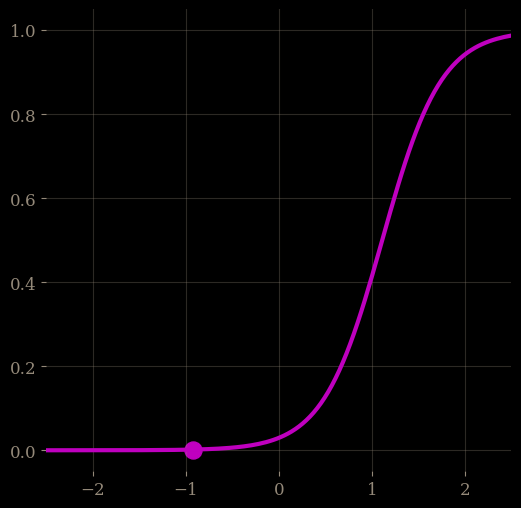

In [43]:
plt.clf()
fig=plt.figure(0, (6, 6), facecolor='k')
ax = fig.add_axes(111,facecolor='k')
ax.plot(vals, res, linewidth=3, c='m');
ax.scatter(vals[40], res[40], s=150, c='m');
ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
plt.xlim([-2.5, 2.5]); plt.ylim([-0.05, 1.05])
style_ax(ax)

  0%|                                                  | 0/128 [00:00<?, ?it/s]/tmp/ipykernel_3484667/29464457.py:4: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (6, 6), facecolor='k')
  0%|                                                  | 0/128 [00:00<?, ?it/s]/tmp/ipykernel_3484667/29464457.py:15: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (6, 6), facecolor='k')
100%|████████████████████████████████████████| 128/128 [00:10<00:00, 12.78it/s]


<Figure size 640x480 with 0 Axes>

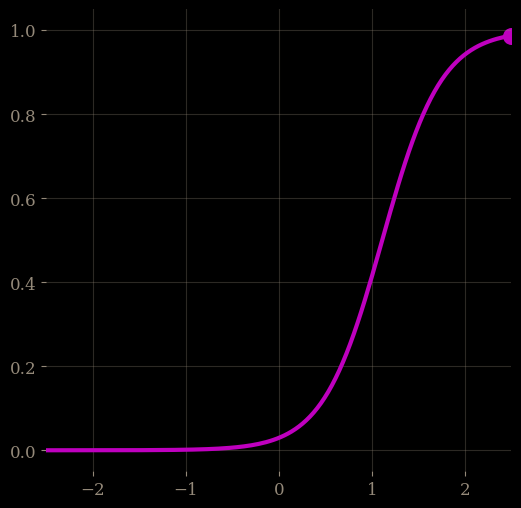

In [44]:
count=0
for i in tqdm(range(len(vals))):
    plt.clf()
    fig=plt.figure(0, (6, 6), facecolor='k')
    ax = fig.add_axes(111,facecolor='k')
    ax.plot(vals[:i], res[:i], linewidth=3, c='m');
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    plt.xlim([-2.5, 2.5]); plt.ylim([-0.05, 1.05])
    style_ax(ax)
    plt.savefig(save_dir/('p26_sweep_1_curve_'+str(count).zfill(3)+'.png'), dpi=300, bbox_inches='tight')
    count+=1

for i in tqdm(range(len(vals))):
    plt.clf()
    fig=plt.figure(0, (6, 6), facecolor='k')
    ax = fig.add_axes(111,facecolor='k')
    ax.plot(vals, res, linewidth=3, c='m');
    ax.scatter(vals[i], res[i], s=125, c='m');
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    plt.xlim([-2.5, 2.5]); plt.ylim([-0.05, 1.05])
    style_ax(ax)
    plt.savefig(save_dir/('p26_sweep_1_curve_'+str(count).zfill(3)+'.png'), dpi=300, bbox_inches='tight')
    count+=1

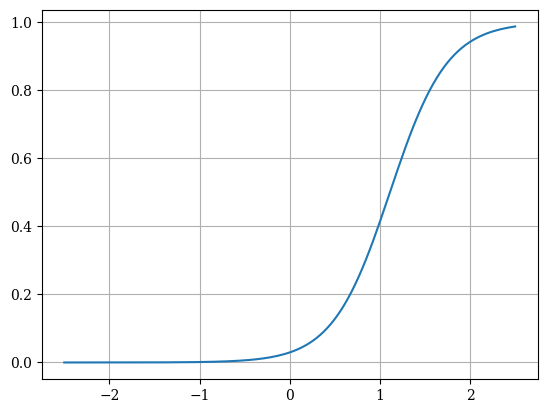

In [45]:
plt.plot(vals, res); plt.grid(1)

## Sweep 2

In [46]:
# save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p26_sweep_2')
# save_dir.mkdir(exist_ok=True)

# li=0 #Fc layer bro
# param_index=0 #220

# name, layer = weighted_layers(model)[li]
# g = layer_grad(model, layer,   x, y)
# vals, idxs = g.abs().topk(TOP_N)

# flat_idx=idxs[param_index].item()
# coord = np.unravel_index(flat_idx, layer.weight.shape)

# with torch.no_grad():
#     w = layer.weight.view(-1)
#     w0 = w[flat_idx].item()
#     vals = np.linspace(-span, span, n)
    
#     for i, v in enumerate(vals):
#         w[flat_idx] = v
#         with ActivationCache(model) as cache:
#             model(x)

#         cache_np={k:v.cpu().numpy() for k,v in cache.items()}
#         np.save(save_dir/str(i).zfill(3), cache_np)

#     w[flat_idx] = w0

## Matplotlib Renders

- Alrighty, so I'm thinking that we render the sweep prob/losss curves (including gradient arrows) in matplotlib, and the probs output curves in matplotlib.
- I want to render some here, and then work on stiching things together in illustrator to get a nice feel for everything and make sure we can make everything fit. 

Hmm ok maybe this is just one color then?

In [47]:
# import numpy as np
# from matplotlib.collections import LineCollection

# probs = torch.nn.Softmax(dim=0)(cache['fc'].ravel()).detach().cpu().numpy()
# y = np.arange(1000)

# # Interpolate along the line so each of the 999 segments becomes ~20 sub-segments
# y_fine = np.linspace(0, 999, 20 * 999 + 1)
# x_fine = np.interp(y_fine, y, probs)

# pts = np.column_stack([x_fine, y_fine]).reshape(-1, 1, 2)
# segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

# fig = plt.figure(0, (2.0, 8), facecolor='k')
# ax = fig.add_subplot(111, facecolor='k')

# lc = LineCollection(segs, cmap='viridis', linewidth=1.5,
#                     capstyle='round', joinstyle='round')
# lc.set_array(x_fine[:-1])       # color = x value, i.e. the probability
# ax.add_collection(lc)

# ax.set_xlim(probs.min(), probs.max())
# ax.set_ylim(999, 0)
# style_ax(ax)

In [48]:
vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, mode='conf')
plt.plot(vals, res); plt.grid(1)

TypeError: conv2d() received an invalid combination of arguments - got (float, Parameter, NoneType, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!float!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!float!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


In [ ]:
@torch.no_grad()
def sweep_weight(model, layer, flat_idx, x, y, mode='loss', span=SPAN, n=N_POINTS):
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(-span, span, n)
    res = np.empty(n)
    for i, v in enumerate(vals):
        w[flat_idx] = v
        if mode=='loss': res[i] = batch_loss_fp32(model, x, y)
        elif mode=='conf': res[i] = correct_ans_conf(model, x, y)
        else: print('nah bro')
    w[flat_idx] = w0

In [ ]:
cache_np={k:v.cpu().numpy() for k,v in cache.items()}
np.save('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p26', cache_np)